In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os, sys
import PIL.Image
import pandas as pd
import pickle
import time, h5py

nsd_path = '/lab_data/hendersonlab/datasets/nsd_preproc'
rois_folder = os.path.join(nsd_path, 'rois')
stim_folder = os.path.join(nsd_path, 'stimuli')
data_folder = os.path.join(nsd_path, 'data')


In [2]:
model_root = '/user_data/junruz/prf_models/no_zscore_drop/'
subject_id = 1
roi_name = 'V1'
model_name = 'RN50'
layer_name='layer2'

model_path = os.path.join(model_root, f"S{subject_id}", model_name, layer_name)
prf_idx_path = os.path.join(model_path, 'best_prf_idx.npy')
r2_path = os.path.join(model_path, 'r2.pkl')

In [3]:
prf_idx = np.load(prf_idx_path)
with open(r2_path, 'rb') as f:
    r2_vals = pickle.load(f)
num_voxels = len(r2_vals[roi_name]['r2_voxels'])
num_voxels

2213

In [4]:
gen_img_root = '/user_data/junruz/BrainDiVE/pRF_no_zscore_ranked/'
gen_img_folder = os.path.join(gen_img_root, f"S{subject_id}_{model_name}_{layer_name}", 'test_step100_scale30.0', 
                              'S1', roi_name)
gen_img_folder

'/user_data/junruz/BrainDiVE/pRF_no_zscore_ranked/S1_RN50_layer2/test_step100_scale30.0/S1/V1'

In [5]:
n = 1 # which voxel
# n = 2

img_list = os.listdir(gen_img_folder)
img_list = [i for i in img_list if 'top%d'%n in i and '.png' in i]

ranks = [int(i.split('_rank')[1].split('_')[0]) for i in img_list]
img_list = np.array(img_list)[np.argsort(ranks)]
img_list

array(['V1_top1_voxel286_rank1_score55.864434_seed1296756507.png',
       'V1_top1_voxel286_rank2_score55.471384_seed4069560025.png',
       'V1_top1_voxel286_rank3_score55.257983_seed1671921994.png',
       'V1_top1_voxel286_rank4_score55.226544_seed2695825663.png',
       'V1_top1_voxel286_rank5_score54.458823_seed2388945667.png',
       'V1_top1_voxel286_rank6_score54.305403_seed3673210076.png',
       'V1_top1_voxel286_rank7_score54.001183_seed2421712592.png',
       'V1_top1_voxel286_rank8_score53.447120_seed909430447.png',
       'V1_top1_voxel286_rank9_score53.388483_seed2404664101.png',
       'V1_top1_voxel286_rank10_score53.092852_seed3558344582.png'],
      dtype='<U57')

In [6]:
# index of this voxel in the current ROI
voxel_ind_in_roi = int(img_list[0].split('_voxel')[1].split('_')[0])
voxel_ind_in_roi

286

In [7]:
rsq = r2_vals[roi_name]['r2_voxels'][voxel_ind_in_roi][0]
rsq

np.float64(0.6588777021200656)

In [8]:

def load_nsd_rois(subject_id):

    roi_path = os.path.join(rois_folder, 'S%d_voxel_roi_info.npy'%subject_id)

    # roi_path = os.path.join(args.roi_path.format(ss))
    # print(f"Loading rois from: {roi_path}")

    roi_info = np.load(roi_path, allow_pickle=True).item()
    noise_ceiling = roi_info['noise_ceiling_avgreps'] / 100.

    big_mask = roi_info['voxel_mask']
    roi_keys = ['roi_labels_retino', 'roi_labels_kastner', 'roi_labels_face', 'roi_labels_place', 'roi_labels_body']
    roi_names = ['ret_prf_roi_names', 'kastner_atlas_roi_names', 'floc_face_roi_names', 'floc_place_roi_names', 'floc_body_roi_names']
    roi_masks = dict()
    for key, name in zip(roi_keys, roi_names):
        roi_labels = roi_info[key][big_mask]
        roi_name = roi_info[name]
        for name in roi_name.keys():
            roi_masks[name] = roi_labels==roi_name[name]
    
    # combine ventral and dorsal retinotopic regions  
    for name in ["V1", "V2", "V3"]:
        roi_masks[name] = roi_masks[name + "v"] | roi_masks[name + "d"]

    # combine FFA-1 and FFA-2
    roi_masks["FFA"] = roi_masks["FFA-1"] | roi_masks["FFA-2"]

    print(f"Loaded {len(roi_masks)} rois: {list(roi_masks.keys())}")
        
    return roi_masks, noise_ceiling

In [9]:
roi_masks, noise_ceiling = load_nsd_rois(subject_id)

roi_inds = np.where( roi_masks[roi_name] & (noise_ceiling>0))[0]
assert(len(roi_inds)==num_voxels)

Loaded 41 rois: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2', 'TO2', 'TO1', 'LO2', 'LO1', 'V3B', 'V3A', 'IPS0', 'IPS1', 'IPS2', 'IPS3', 'IPS4', 'IPS5', 'SPL1', 'FEF', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'V1', 'V2', 'V3', 'FFA']


In [10]:
# which voxel is this in the big list
voxel_ind = roi_inds[voxel_ind_in_roi]
# what is prf of this voxel
voxel_prf_ind = prf_idx[voxel_ind]

voxel_ind, voxel_prf_ind

(np.int64(8066), np.int64(361))

In [11]:
sys.path.append('/lab_data/hendersonlab/code/feature_extraction/')
import prf_utils
prf_grid, _ = prf_utils.get_prf_grid(grid_name = 'default-log-polar')
prf_grid

x, y, sigma = prf_grid[voxel_prf_ind]
x, y, sigma

(np.float32(0.31716165), np.float32(0.13137268), np.float32(0.047706645))

In [12]:
# load raw NSD data and images
data_filename = os.path.join(stim_folder, 'S%d_stimuli_224.h5py'%subject_id)
print(data_filename)

t = time.time()
with h5py.File(data_filename, 'r') as data_set:
    images = np.copy(data_set['/stimuli'])
    data_set.close() 
elapsed = time.time() - t
print('Took %.5f seconds to load file'%elapsed)

data_filename = os.path.join(data_folder, 'S%d_betas_avg_bigmask.hdf5'%subject_id)
print(data_filename)

t = time.time()
with h5py.File(data_filename, 'r') as data_set:
    voxel_data = np.copy(data_set['/betas'])
    data_set.close() 
elapsed = time.time() - t
print('Took %.5f seconds to load file'%elapsed)


/lab_data/hendersonlab/datasets/nsd_preproc/stimuli/S1_stimuli_224.h5py
Took 0.23396 seconds to load file
/lab_data/hendersonlab/datasets/nsd_preproc/data/S1_betas_avg_bigmask.hdf5
Took 0.45863 seconds to load file


In [13]:
# get the top images
vv = voxel_ind

image_ordering = np.argsort(voxel_data[:,vv])
top_n = 10
top_trials = np.flip(image_ordering)[0:top_n]

### Plot true top images

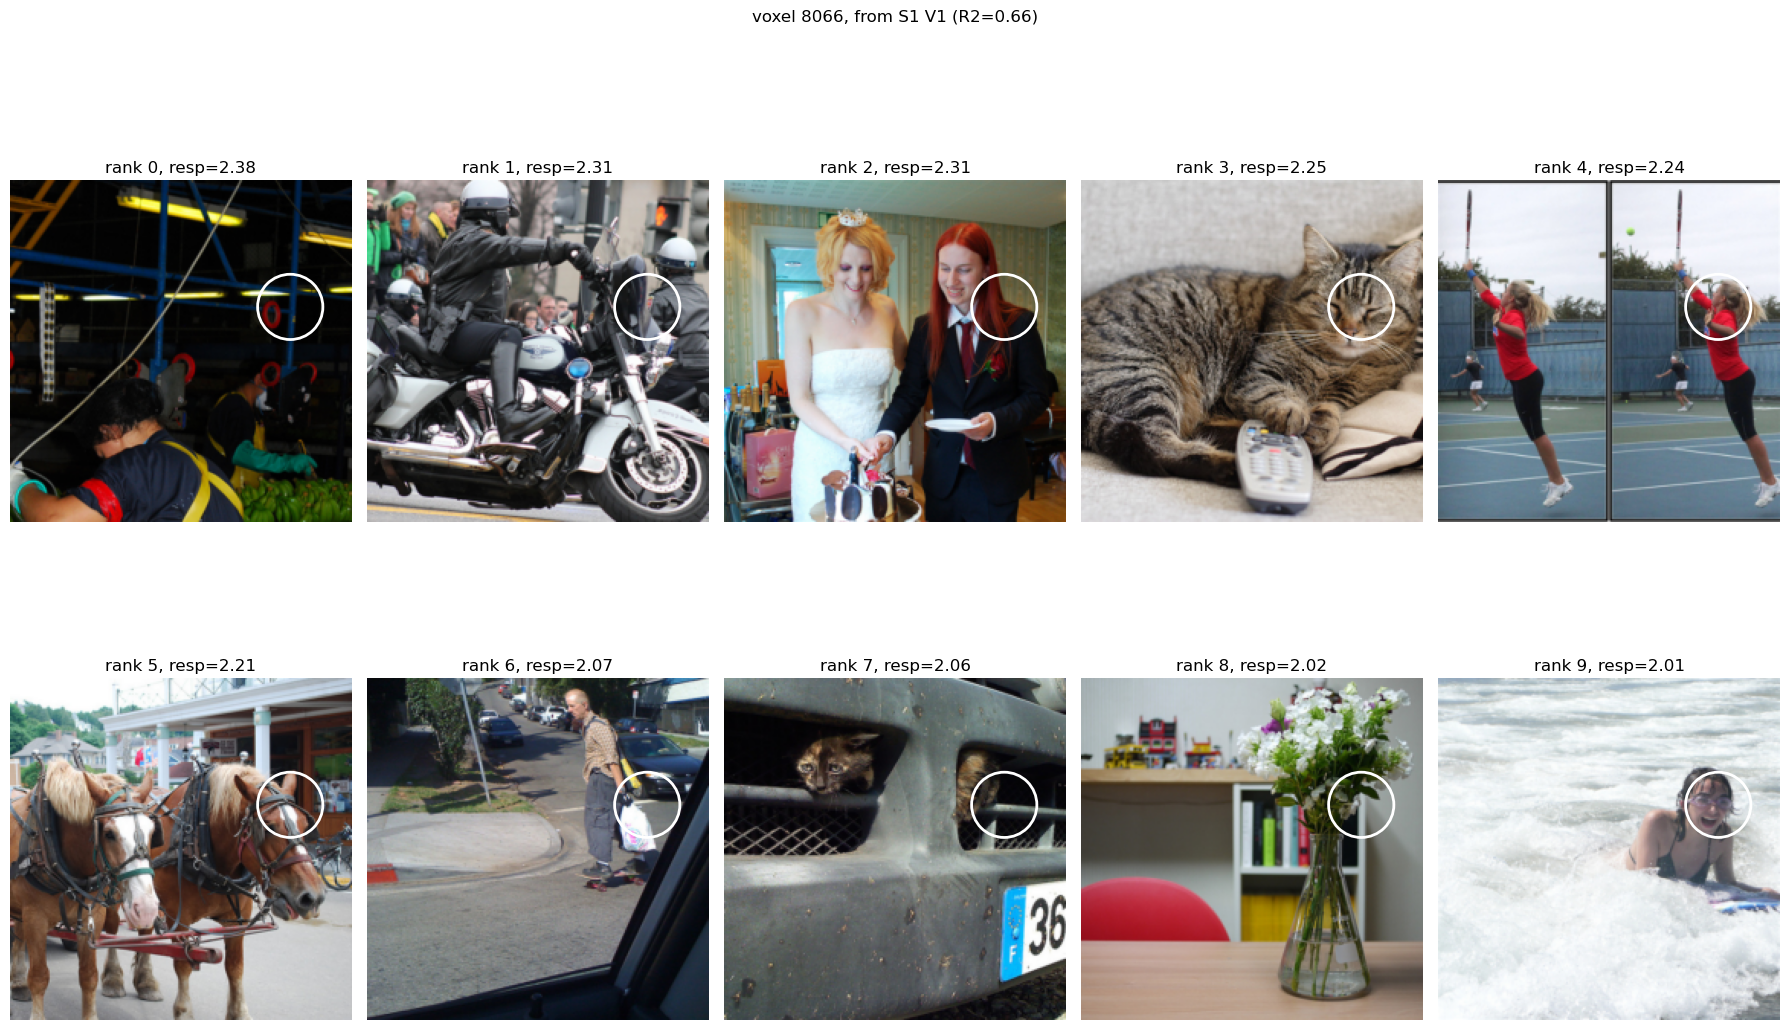

In [14]:
n_pix = images.shape[2]
prf_2d = prf_utils.gauss_2d(center=[x,y], sd=sigma, patch_size=n_pix)

# Next we convert the values into image coordinates, relative to actual n_pix
# invert y direction here for imshow
center_in_image = np.array((n_pix/2 + x*n_pix, n_pix/2 - n_pix*y))
size_in_image = 2*sigma*n_pix

plt.figure(figsize=(18,12));
for ii, index in enumerate(top_trials):
    ax = plt.subplot(2,5,ii+1);
    image = np.moveaxis(images[index], [0], [2])
    plt.imshow(image, cmap='gray')
    circ = matplotlib.patches.Circle(center_in_image, size_in_image, 
                                                 color = 'w', fill=False, lw=2)
    ax.add_artist(circ)
    plt.axis('off')
    plt.title('rank %d, resp=%.2f'%(ii, voxel_data[index,vv]))

    
plt.suptitle('voxel %d, from S%d %s (R2=%.2f)'%(vv, subject_id, roi_name, rsq))

plt.tight_layout()

### Plot top generated images

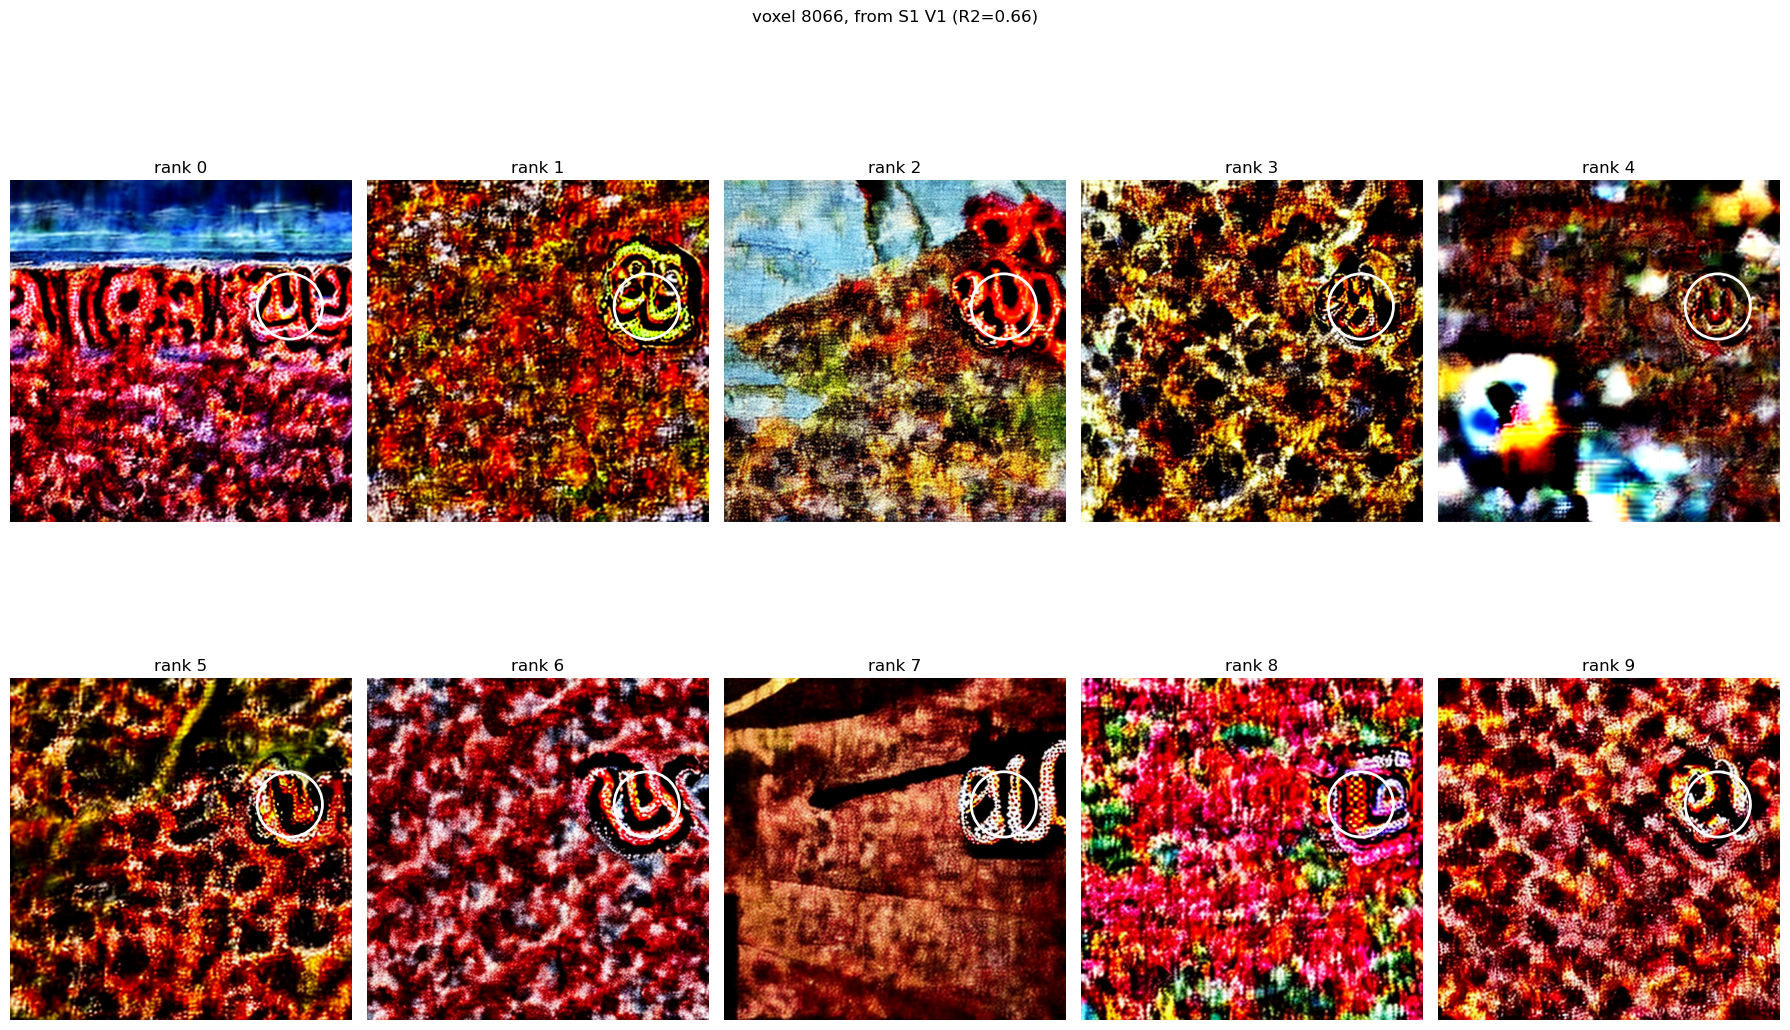

In [15]:
n_pix = 512
prf_2d = prf_utils.gauss_2d(center=[x,y], sd=sigma, patch_size=n_pix)

# Next we convert the values into image coordinates, relative to actual n_pix
# invert y direction here for imshow
center_in_image = np.array((n_pix/2 + x*n_pix, n_pix/2 - n_pix*y))
size_in_image = 2*sigma*n_pix

plt.figure(figsize=(18,12));

for ii, im_fn in enumerate(img_list):
    ax = plt.subplot(2,5,ii+1);

    im = PIL.Image.open(os.path.join(gen_img_folder, im_fn))
    plt.imshow(im)
    circ = matplotlib.patches.Circle(center_in_image, size_in_image, 
                                                 color = 'w', fill=False, lw=2)
    ax.add_artist(circ)
    plt.axis('off')
    plt.title('rank %d'%(ii))


plt.suptitle('voxel %d, from S%d %s (R2=%.2f)'%(vv, subject_id, roi_name, rsq))

plt.tight_layout()

### Same thing but weighting by the pRF as a mask

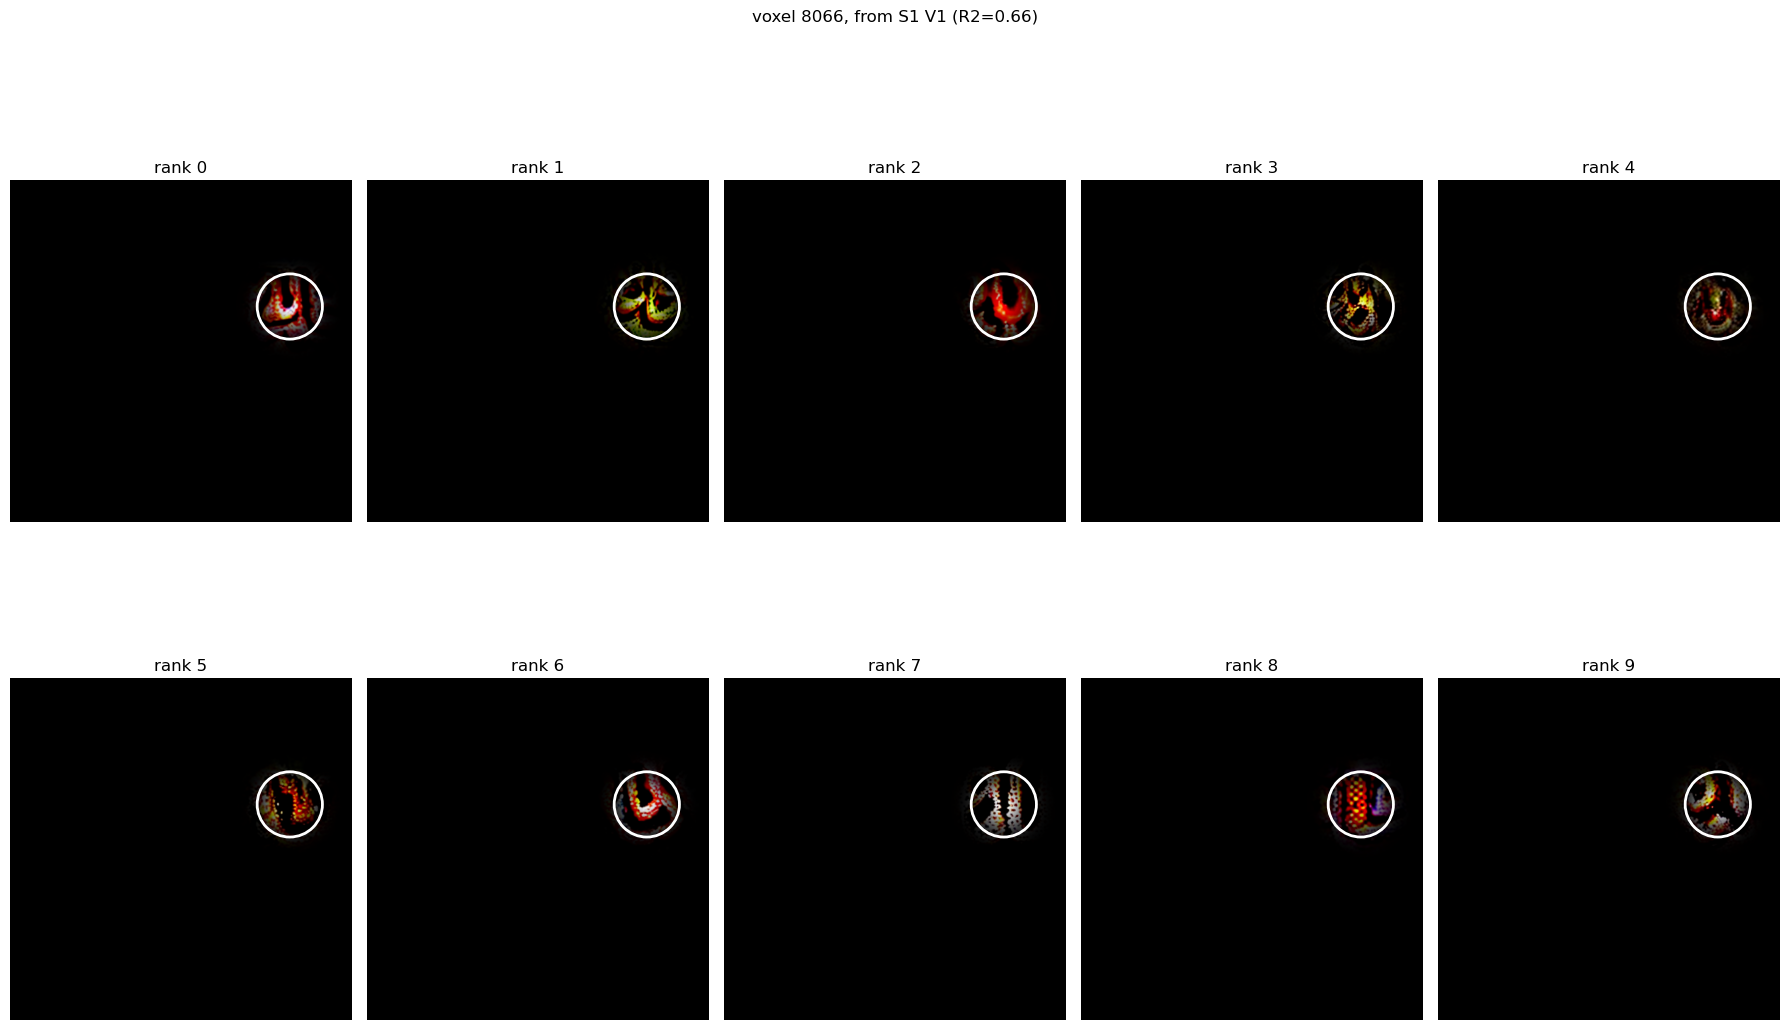

In [16]:
n_pix = 512
prf_2d = prf_utils.gauss_2d(center=[x,y], sd=sigma, patch_size=n_pix)

# Next we convert the values into image coordinates, relative to actual n_pix
# invert y direction here for imshow
center_in_image = np.array((n_pix/2 + x*n_pix, n_pix/2 - n_pix*y))
size_in_image = 2*sigma*n_pix

xlims = [np.floor(center_in_image[0] - size_in_image)-10, np.ceil(center_in_image[0] + size_in_image)+10]
ylims = [np.floor(center_in_image[1] - size_in_image)-10, np.ceil(center_in_image[1] + size_in_image)+10]

plt.figure(figsize=(18,12));

for ii, im_fn in enumerate(img_list):
    ax = plt.subplot(2,5,ii+1);

    im = PIL.Image.open(os.path.join(gen_img_folder, im_fn))

    # Convert image to float numpy array
    img_array = np.array(im).astype(np.float32)  # shape: (512, 512, 3)
    
    # Expand mask to match RGB channels: (512, 512) -> (512, 512, 1)
    mask_3d = prf_2d[:, :, np.newaxis]  # broadcasts across R, G, B
    mask_3d = mask_3d/np.max(mask_3d)
    
    # Apply the weight
    weighted = img_array * mask_3d

    # Clip to valid range and convert back to uint8
    weighted = np.clip(weighted, 0, 255).astype(np.uint8)
    
    im_weighted = PIL.Image.fromarray(weighted)
    
    plt.imshow(im_weighted)
    circ = matplotlib.patches.Circle(center_in_image, size_in_image, 
                                                 color = 'w', fill=False, lw=2)
    ax.add_artist(circ)
    plt.axis('off')
    plt.title('rank %d'%(ii))

    # plt.xlim(xlims)
    # plt.ylim(ylims)


plt.suptitle('voxel %d, from S%d %s (R2=%.2f)'%(vv, subject_id, roi_name, rsq))

plt.tight_layout()

### Zoom in/crop

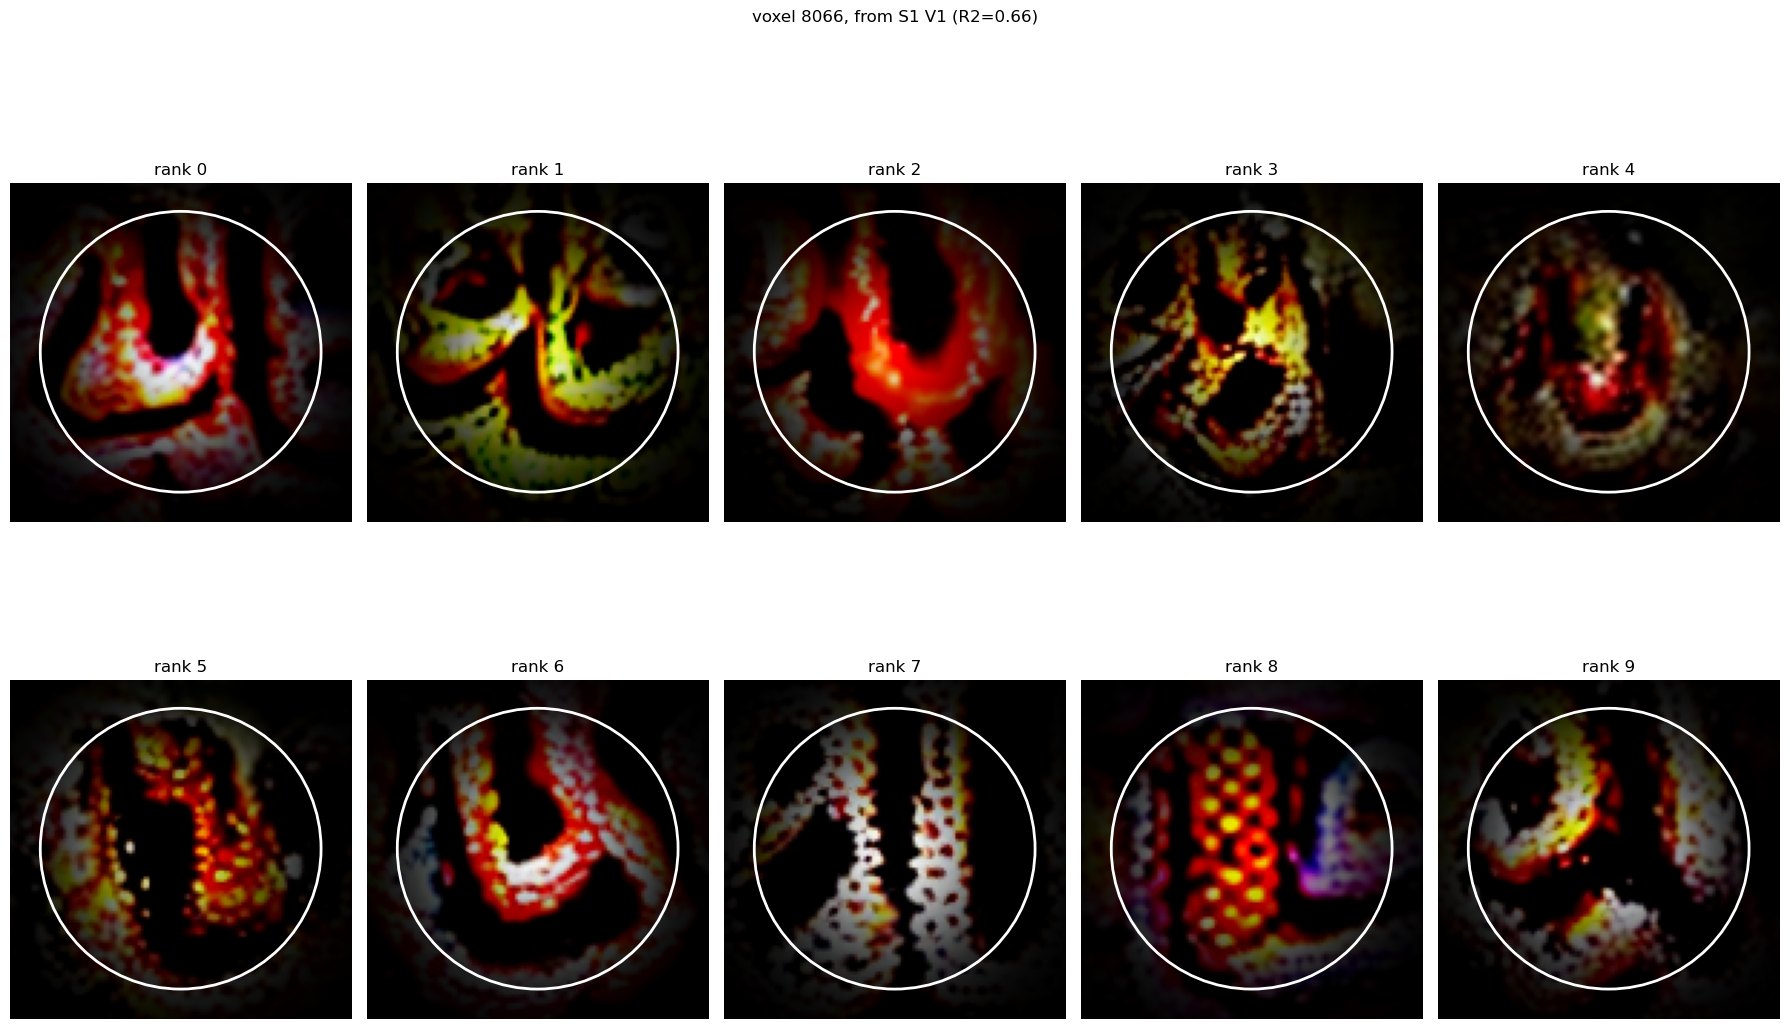

In [17]:
n_pix = 512
prf_2d = prf_utils.gauss_2d(center=[x,y], sd=sigma, patch_size=n_pix)

# Next we convert the values into image coordinates, relative to actual n_pix
# invert y direction here for imshow
center_in_image = np.array((n_pix/2 + x*n_pix, n_pix/2 - n_pix*y))
size_in_image = 2*sigma*n_pix

xlims = [np.floor(center_in_image[0] - size_in_image*1.2), np.ceil(center_in_image[0] + size_in_image*1.2)]
ylims = [np.floor(center_in_image[1] - size_in_image*1.2), np.ceil(center_in_image[1] + size_in_image*1.2)]
ylims = np.flip(ylims) # so that it doesn't flip the image

plt.figure(figsize=(18,12));

for ii, im_fn in enumerate(img_list):
    ax = plt.subplot(2,5,ii+1);

    im = PIL.Image.open(os.path.join(gen_img_folder, im_fn))

    # Convert image to float numpy array
    img_array = np.array(im).astype(np.float32)  # shape: (512, 512, 3)
    
    # Expand mask to match RGB channels: (512, 512) -> (512, 512, 1)
    mask_3d = prf_2d[:, :, np.newaxis]  # broadcasts across R, G, B
    mask_3d = mask_3d/np.max(mask_3d)
    
    # Apply the weight
    weighted = img_array * mask_3d

    # Clip to valid range and convert back to uint8
    weighted = np.clip(weighted, 0, 255).astype(np.uint8)
    
    im_weighted = PIL.Image.fromarray(weighted)
    
    plt.imshow(im_weighted)
    circ = matplotlib.patches.Circle(center_in_image, size_in_image, 
                                                 color = 'w', fill=False, lw=2)
    ax.add_artist(circ)
    plt.axis('off')
    plt.title('rank %d'%(ii))

    plt.xlim(xlims)
    plt.ylim(ylims)


plt.suptitle('voxel %d, from S%d %s (R2=%.2f)'%(vv, subject_id, roi_name, rsq))

plt.tight_layout()


In [230]:
ylims

[np.float32(129.0), np.float32(248.0)]

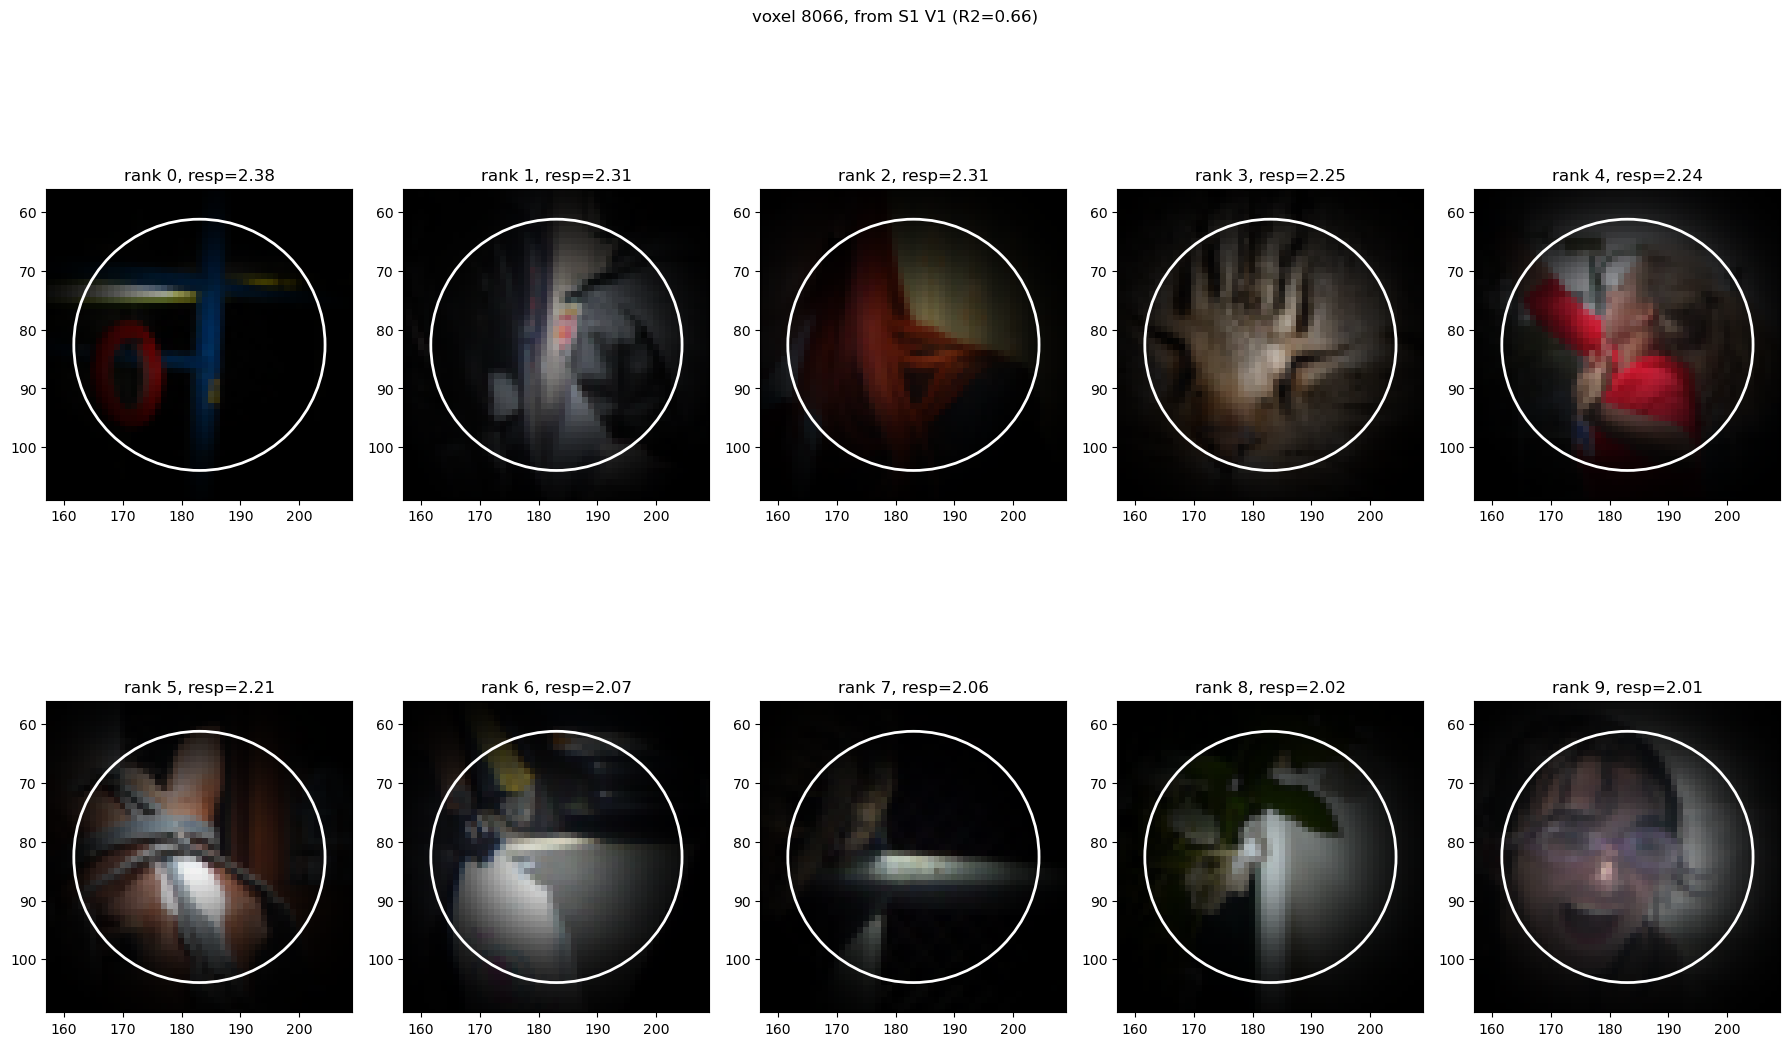

In [18]:
n_pix = images.shape[2]
prf_2d = prf_utils.gauss_2d(center=[x,y], sd=sigma, patch_size=n_pix)

# Next we convert the values into image coordinates, relative to actual n_pix
# invert y direction here for imshow
center_in_image = np.array((n_pix/2 + x*n_pix, n_pix/2 - n_pix*y))
size_in_image = 2*sigma*n_pix

xlims = [np.floor(center_in_image[0] - size_in_image*1.2), np.ceil(center_in_image[0] + size_in_image*1.2)]
ylims = [np.floor(center_in_image[1] - size_in_image*1.2), np.ceil(center_in_image[1] + size_in_image*1.2)]
ylims = np.flip(ylims) # so that it doesn't flip the image

plt.figure(figsize=(18,12));
for ii, index in enumerate(top_trials):
    ax = plt.subplot(2,5,ii+1);
    
    img_array = np.moveaxis(images[index], [0], [2])

    # # Convert image to float numpy array
    # img_array = np.array(im).astype(np.float32)  # shape: (512, 512, 3)
    
    # Expand mask to match RGB channels: (512, 512) -> (512, 512, 1)
    mask_3d = prf_2d[:, :, np.newaxis]  # broadcasts across R, G, B
    mask_3d = mask_3d/np.max(mask_3d)
    
    # Apply the weight
    weighted = img_array * mask_3d

    # Clip to valid range and convert back to uint8
    weighted = np.clip(weighted, 0, 255).astype(np.uint8)
    
    im_weighted = PIL.Image.fromarray(weighted)
    
    plt.imshow(im_weighted)
    
    # plt.imshow(image, cmap='gray')
    circ = matplotlib.patches.Circle(center_in_image, size_in_image, 
                                                 color = 'w', fill=False, lw=2)
    ax.add_artist(circ)
    # plt.axis('off')
    plt.title('rank %d, resp=%.2f'%(ii, voxel_data[index,vv]))

    plt.xlim(xlims)
    plt.ylim(ylims)

    
plt.suptitle('voxel %d, from S%d %s (R2=%.2f)'%(vv, subject_id, roi_name, rsq))

plt.tight_layout()